In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

In [ ]:
class LLM_Prompts(TypedDict):
    title: str
    outline: str
    content: str
    evaluate: str

In [10]:
def generate_outline(state: LLM_Prompts)->LLM_Prompts:
    title = state['title']

    prompt = f"Generate an outline for the following title {title}"

    outline = model.invoke(prompt).content

    state['outline'] = outline
    return state

def generate_content(state: LLM_Prompts)->LLM_Prompts:
    outline = state['outline']

    prompt = f"Generate the content for the following outline {outline}"

    content = model.invoke(prompt).content

    state['content'] = content
    return state

def evaluate_content(state: LLM_Prompts)->LLM_Prompts:
    outline = state['outline']
    content = state['content']

    prompt = f'Based on this outline {outline}, Rate my content {content}'

    evaluate = model.invoke(prompt).content

    state['evaluate'] = evaluate
    return state

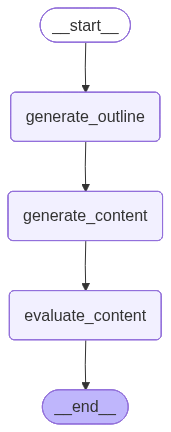

In [11]:
graph = StateGraph(LLM_Prompts)

graph.add_node('generate_outline', generate_outline)
graph.add_node('generate_content', generate_content)
graph.add_node('evaluate_content', evaluate_content)

graph.add_edge(START, 'generate_outline')
graph.add_edge('generate_outline', 'generate_content')
graph.add_edge('generate_content', 'evaluate_content')
graph.add_edge('evaluate_content', END)

workflow = graph.compile()
workflow

In [ ]:
input = {'title': 'Pros and Cons of AI'}
workflow.invoke(input)